In [6]:
raise RuntimeError("Superseded: re-running this notebook would overwrite the corrected splits. See notebook 06.")

RuntimeError: Superseded: re-running this notebook would overwrite the corrected splits. See notebook 06.

> **Superseded.** This notebook made the original hold-out split by segment. That split was later found to leak, because near-copy segments could land on both sides (see notebook 06). The corrected splits are in `splits/`. The code cell below stops the notebook on purpose, so a re-run cannot overwrite them. The outputs shown are from the original run.

In [1]:
import sys
sys.path.append("../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw, load_binary, split_holdout, feature_cols
from src.config import PROCESSED, FIGURES, RANDOM_STATE

PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

df = load_raw()
cols = feature_cols(df)
binary = load_binary()

dev, hold = split_holdout(binary)

dev.to_csv(PROCESSED / "dev_2v3.csv", index=False)
hold.to_csv(PROCESSED / "holdout_2v3.csv", index=False)

pool = df[~df["segment"].isin(hold["segment"])].copy()
pool["chunk_std"] = pool[cols].std(axis=1)

print(df.shape, dev.shape, hold.shape, pool.shape)
print(dev["y"].value_counts().to_dict(), hold["y"].value_counts().to_dict())



(11500, 182) (3680, 182) (920, 182) (10580, 183)
{2: 1840, 3: 1840} {2: 460, 3: 460}


In [2]:
seg = df.groupby("segment")
print("rows per segment:", seg.size().value_counts().to_dict()) 
print("distinct chunk numbers per segment:", seg["chunk"].nunique().value_counts().to_dict())
print("classes per segment:", seg["y"].nunique().value_counts().to_dict())
print("segments per class:", seg["y"].first().value_counts().sort_index().to_dict())  

rows per segment: {23: 500}
distinct chunk numbers per segment: {23: 500}
classes per segment: {1: 500}
segments per class: {1: 100, 2: 100, 3: 100, 4: 100, 5: 100}


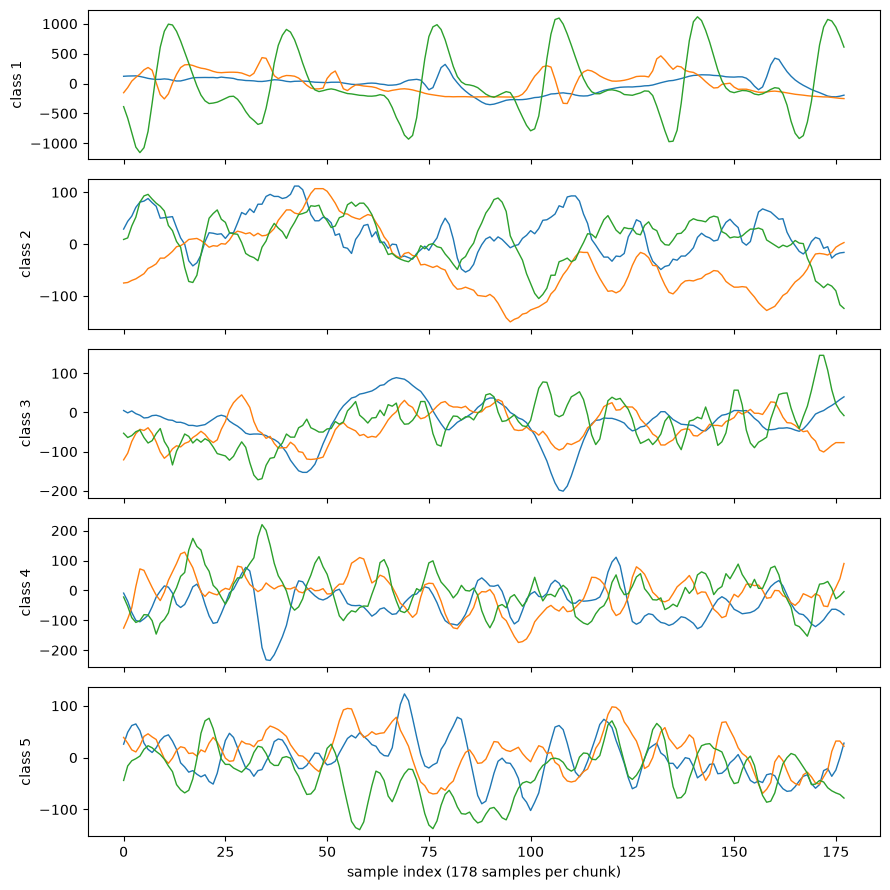

In [3]:
rng = np.random.default_rng(RANDOM_STATE)
t = np.arange(178)
fig, axes = plt.subplots(5, 1, figsize=(9, 9), sharex=True)
for ax, c in zip(axes, [1, 2, 3, 4, 5]):
    sub = pool[pool["y"] == c]
    for i in rng.choice(sub.index, 3, replace=False):
        ax.plot(t, sub.loc[i, cols].to_numpy(dtype=float), lw=1)
    ax.set_ylabel(f"class {c}")
axes[-1].set_xlabel("sample index (178 samples per chunk)")
plt.tight_layout()
plt.savefig(FIGURES / "02_example_chunks.png", dpi=150)
plt.show()

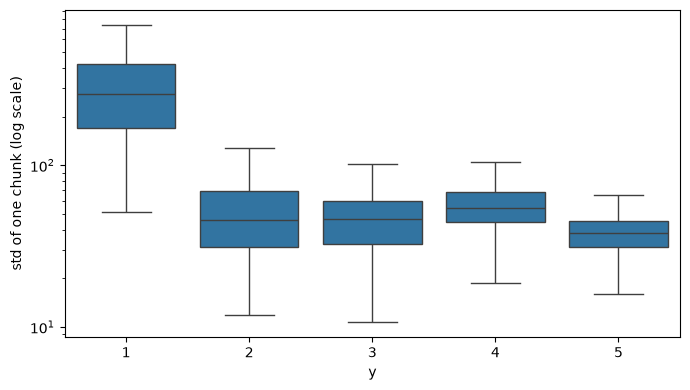

{1: 277.4, 2: 45.7, 3: 46.2, 4: 54.5, 5: 38.1}


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=pool, x="y", y="chunk_std", ax=ax, showfliers=False)
ax.set_yscale("log")
ax.set_ylabel("std of one chunk (log scale)")
plt.tight_layout()
plt.savefig(FIGURES / "03_amplitude_by_class.png", dpi=150)
plt.show()
print(pool.groupby("y")["chunk_std"].median().round(1).to_dict())

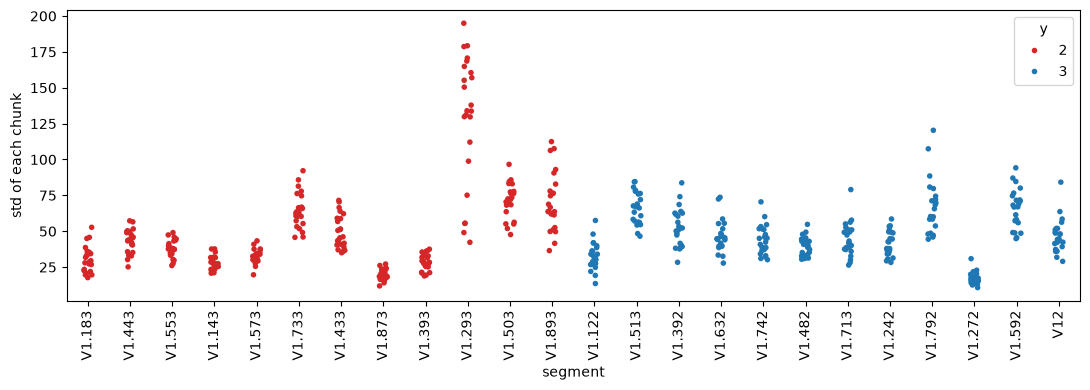

share of variance explained by segment: 0.74


In [5]:
d = pool[pool["y"].isin([2, 3])].copy()
chosen = {c: list(rng.choice(sorted(d[d["y"] == c]["segment"].unique()), 12, replace=False))
          for c in [2, 3]}
order = chosen[2] + chosen[3]
sub = d[d["segment"].isin(order)].copy()
sub["segment"] = pd.Categorical(sub["segment"], categories=order, ordered=True)

fig, ax = plt.subplots(figsize=(11, 4))
sns.stripplot(data=sub, x="segment", y="chunk_std", hue="y",
              palette={2: "tab:red", 3: "tab:blue"}, size=4, ax=ax)
ax.tick_params(axis="x", rotation=90)
ax.set_ylabel("std of each chunk")
plt.tight_layout()
plt.savefig(FIGURES / "04_chunks_cluster_by_segment.png", dpi=150)
plt.show()

d["log_std"] = np.log(d["chunk_std"])
share = d.groupby("segment")["log_std"].transform("mean").var() / d["log_std"].var()
print("share of variance explained by segment:", round(share, 2))

# 01 Audit: findings

**Task:** tell class 2 ("tumour area") from class 3 ("healthy area") using 1-second EEG chunks.

## The data
- 11,500 rows = 500 segments x 23 chunks. A segment is the group of 23 rows that share the same ID ending (e.g. `V1.791`).
- Each segment has chunks 1 to 23 once each and belongs to one class. There are 100 segments per class.
- Classes 2 and 3 together: 200 segments, 4,600 rows.

## The split
- 20% of segments in each class are held out for the final test: 40 segments, 920 rows.
- Development set: 160 segments, 3,680 rows (1,840 per class).
- Whole segments are held out, never single chunks.